# Download overlapping EMIT and AVIRIS-3 scenes and convolve

Video Tutorial: [Tutorial Part 1](https://www.loom.com/share/8d1c569874be43bcbef2eb4381b16586) and [Tutorial Part 2](https://www.loom.com/share/824acc2fb079479f85d3f13ced370245)

End-to-end tutorial using real NASA Earthdata acquisitions over the Angeles National Forest, CA.

**Instruments used**

| | EMIT | AVIRIS-3 |
|---|---|---|
| Platform | ISS (spaceborne) | Airborne |
| Acquisition | 2024-08-25 | 2024-09-05 |
| Bands | 288 good, 366-2500 nm | 284, 390-2494 nm |
| FWHM | 8.4-8.8 nm (nominal) | 7.62-8.31 nm (real file) |
| Collection | EMITL2ARFL v001 @ LP DAAC | AV3_L2A_RFL_2357 v1 @ ORNL DAAC |

We download the AVIRIS-3 granule (~886 MB), convolve it to EMIT spectral sampling
using `srfforge`, and compare the results.

**Note on the EMIT download:** we use the bundled nominal EMIT wavelengths rather than
downloading the full 1.8 GB EMIT product. The per-acquisition band centers differ
negligibly from the nominal values. To use a real EMIT product file instead:
```python
emit = EMIT(srf_file="EMIT_L2A_RFL_001_20240825T173115_2423811_008.nc")
```


---
## 1. Setup

### Option A — conda (recommended)
Creates an isolated environment with all dependencies pre-solved:
```bash
# from the srfforge repo root
conda env create -f environment.yml
conda activate srfforge
```

### Option B — pip into an existing environment
```bash
# from the srfforge repo root
pip install -e ".[tutorials]"   # earthaccess + matplotlib only
pip install -e ".[full]"        # everything including search/plot extras
```

### NASA Earthdata account
1. Register (free) at https://urs.earthdata.nasa.gov/users/new
2. Run the login cell once — credentials are saved to `~/.netrc` for future sessions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from pathlib import Path

import earthaccess

from srfforge import BandConvolver, EMIT, AVIRIS3
from srfforge.io import read_aviris3_nc


/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# persist=True saves credentials to ~/.netrc so you only need to do this once
auth = earthaccess.login(persist=True)
print("Authenticated:", auth.authenticated)


Authenticated: True


---
## 2. Search region

Bounding box `(west, south, east, north)` over the Angeles National Forest, CA.
Varied land cover (chaparral, conifer forest, urban edges) makes it a good test scene.


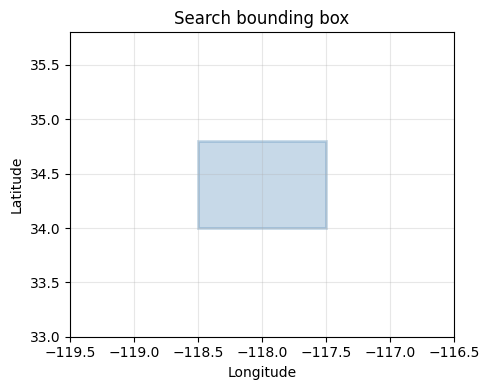

In [3]:
# (west, south, east, north) in decimal degrees
BBOX = (-118.5, 34.0, -117.5, 34.8)

fig, ax = plt.subplots(figsize=(5, 4))
rect = mpatches.Rectangle(
    (BBOX[0], BBOX[1]), BBOX[2] - BBOX[0], BBOX[3] - BBOX[1],
    linewidth=2, edgecolor="steelblue", facecolor="steelblue", alpha=0.3,
)
ax.add_patch(rect)
ax.set_xlim(BBOX[0] - 1, BBOX[2] + 1)
ax.set_ylim(BBOX[1] - 1, BBOX[3] + 1)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Search bounding box")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 3. Search for granules

Neither product supports on-demand spatial subsetting, so full granules are downloaded.

| Collection | Short name | DAAC |
|---|---|---|
| EMIT L2A Reflectance | EMITL2ARFL v001 | LP DAAC |
| AVIRIS-3 L2A Reflectance | AV3_L2A_RFL_2357 v1 | ORNL DAAC |


In [8]:
emit_results = earthaccess.search_data(
    short_name="EMITL2ARFL", version="001", bounding_box=BBOX, count=100,
)
av3_results = earthaccess.search_data(
    short_name="AV3_L2A_RFL_2357", version="1", bounding_box=BBOX, count=100,
)
print(f"EMIT granules found    : {len(emit_results)}")
print(f"AVIRIS-3 granules found: {len(av3_results)}")


/opt/miniconda3/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


EMIT granules found    : 100
AVIRIS-3 granules found: 100


---
## 4. Find overlapping granule pairs

Extract bounding boxes from CMR metadata, find overlapping pairs, rank by overlap area.

All AVIRIS-3 granules here are from one flight day: **2024-09-05**.
The closest EMIT acquisition is **2024-08-25** (11 days prior).


In [9]:
def get_bbox(g):
    """Return (west, south, east, north) from a CMR DataGranule."""
    geom = (
        g["umm"].get("SpatialExtent", {})
        .get("HorizontalSpatialDomain", {})
        .get("Geometry", {})
    )
    if "BoundingRectangles" in geom:
        bb = geom["BoundingRectangles"][0]
        return (bb["WestBoundingCoordinate"], bb["SouthBoundingCoordinate"],
                bb["EastBoundingCoordinate"], bb["NorthBoundingCoordinate"])
    pts = geom["GPolygons"][0]["Boundary"]["Points"]
    lons = [p["Longitude"] for p in pts]
    lats = [p["Latitude"] for p in pts]
    return (min(lons), min(lats), max(lons), max(lats))

def overlap_area(a, b):
    w = max(0, min(a[2], b[2]) - max(a[0], b[0]))
    h = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    return w * h

def get_time(g):
    return g["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"][:10]

def get_ur(g):
    return g["umm"]["GranuleUR"]


emit_aug25 = [g for g in emit_results if get_time(g) == "2024-08-25"]
emit_combined_bbox = (
    min(get_bbox(g)[0] for g in emit_aug25),
    min(get_bbox(g)[1] for g in emit_aug25),
    max(get_bbox(g)[2] for g in emit_aug25),
    max(get_bbox(g)[3] for g in emit_aug25),
)
print(f"EMIT 2024-08-25 granules : {len(emit_aug25)}")
print(f"Combined EMIT bbox       : {tuple(round(x, 2) for x in emit_combined_bbox)}")
print()

scored = sorted(
    [(overlap_area(emit_combined_bbox, get_bbox(g)), g) for g in av3_results],
    reverse=True,
)
print("Top 5 AVIRIS-3 granules by overlap with EMIT 2024-08-25:")
for area, g in scored[:150]:
    bb = get_bbox(g)
    w_km = max(0, min(bb[2], emit_combined_bbox[2]) - max(bb[0], emit_combined_bbox[0])) * 111
    h_km = max(0, min(bb[3], emit_combined_bbox[3]) - max(bb[1], emit_combined_bbox[1])) * 111
    print(f"  {get_ur(g)}  overlap ~{w_km:.1f} x {h_km:.1f} km")


EMIT 2024-08-25 granules : 2
Combined EMIT bbox       : (-119.58, 33.26, -117.75, 34.94)

Top 5 AVIRIS-3 granules by overlap with EMIT 2024-08-25:
  AV320240905t184546_009_L2A_RFL_1  overlap ~11.6 x 7.7 km
  AV320240905t185532_010_L2A_RFL_1  overlap ~10.3 x 7.2 km
  AV320240905t183620_009_L2A_RFL_1  overlap ~10.4 x 7.1 km
  AV320240905t191511_012_L2A_RFL_1  overlap ~10.2 x 7.2 km
  AV320240905t181848_009_L2A_RFL_1  overlap ~8.5 x 6.3 km
  AV320240905t182728_011_L2A_RFL_1  overlap ~7.5 x 5.9 km
  AV320240905t184546_008_L2A_RFL_1  overlap ~7.3 x 5.8 km
  AV320240905t184546_006_L2A_RFL_1  overlap ~7.3 x 5.8 km
  AV320240905t184546_007_L2A_RFL_1  overlap ~7.3 x 5.7 km
  AV320240905t184546_005_L2A_RFL_1  overlap ~7.3 x 5.8 km
  AV320240905t184546_004_L2A_RFL_1  overlap ~7.3 x 5.7 km
  AV320240905t184546_003_L2A_RFL_1  overlap ~7.2 x 5.7 km
  AV320240905t191511_004_L2A_RFL_1  overlap ~6.9 x 5.9 km
  AV320240905t184546_002_L2A_RFL_1  overlap ~7.2 x 5.6 km
  AV320240905t184546_001_L2A_RFL_1  o

In [10]:
# Chosen granule: best overlap with EMIT 2024-08-25 AND smallest file size (886 MB)
# Overlap with EMIT_L2A_RFL_001_20240825T173115_2423811_008: ~6.3 x 5.0 km
chosen_av3 = next(g for g in av3_results
                  if get_ur(g) == "AV320240905t182728_000_L2A_RFL_1")

print(f"Granule : {get_ur(chosen_av3)}")
print(f"Date    : {get_time(chosen_av3)}")
print(f"Bbox    : {tuple(round(x, 2) for x in get_bbox(chosen_av3))}")
print()
print("Files in this granule:")
for link in chosen_av3.data_links():
    print(f"  {link.split(chr(47))[-1]}")


Granule : AV320240905t182728_000_L2A_RFL_1
Date    : 2024-09-05
Bbox    : (-118.14, 34.17, -118.09, 34.21)

Files in this granule:
  AV320240905t182728_000_L2A_OE_f576f24d_RFL_ORT.nc
  AV320240905t182728_000_L2A_OE_f576f24d_UNC_ORT.nc
  AV320240905t182728_000_L2A_OE_f576f24d_RFL_ORT_QL.tif
  AV320240905t182728_000_L2A_OE_f576f24d.yaml


---
## 5. Download

File inventory for this granule:
- `_RFL_ORT.nc` — orthorectified surface reflectance (886 MB) **we need this**
- `_UNC_ORT.nc` — per-pixel uncertainty (872 MB)
- `_RFL_ORT_QL.tif` — RGB quicklook GeoTIFF (4 MB)
- `.yaml` — processing metadata

`earthaccess.download` fetches all files in the granule.
We skip the EMIT file (1.8 GB) and use the bundled nominal wavelengths.


In [11]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

av3_files = earthaccess.download([chosen_av3], local_path=data_dir)

print("Downloaded:")
for f in av3_files:
    size_mb = Path(f).stat().st_size / 1e6
    print(f"  {Path(f).name}  ({size_mb:.0f} MB)")


/opt/miniconda3/lib/python3.13/site-packages/earthaccess/store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 4/4 [00:00<00:00, 565.21it/s]
PROCESSING TASKS | : 100%|██████████| 4/4 [00:00<00:00, 58052.65it/s]
COLLECTING RESULTS | : 100%|██████████| 4/4 [00:00<00:00, 138654.68it/s]

Downloaded:
  AV320240905t182728_000_L2A_OE_f576f24d_RFL_ORT.nc  (886 MB)
  AV320240905t182728_000_L2A_OE_f576f24d_UNC_ORT.nc  (872 MB)
  AV320240905t182728_000_L2A_OE_f576f24d_RFL_ORT_QL.tif  (4 MB)
  AV320240905t182728_000_L2A_OE_f576f24d.yaml  (0 MB)


---
## 6. Load the AVIRIS-3 file

`read_aviris3_nc` reads the `reflectance` group and transposes from
bands-first `(284, 1532, 1605)` to `(1532, 1605, 284)` so the band axis is last.

Confirmed file structure:
```
/reflectance/
    reflectance   (284, 1532, 1605)  float32   bands x lines x cols
    wavelength    (284,)             float32   nm, 389.8 to 2493.5
    fwhm          (284,)             float32   nm, 7.62 to 8.31
/easting          (1605,)            float64
/northing         (1532,)            float64
/aerosol_optical_thickness/...
/water_vapor/...
```


In [12]:
av3_nc = next(f for f in av3_files if Path(f).name.endswith("_RFL_ORT.nc"))

av3_data, av3, av3_meta = read_aviris3_nc(av3_nc)

# Replace fill value with NaN before any arithmetic
av3_data[av3_data == av3_meta["no_data"]] = np.nan

print(f"Shape      : {av3_data.shape}  (lines, cols, bands)")
print(f"Bands      : {len(av3.wavelengths)}  ({av3.wavelengths[0]:.1f} - {av3.wavelengths[-1]:.1f} nm)")
print(f"FWHM range : {av3.fwhm.min():.2f} - {av3.fwhm.max():.2f} nm")
print(av3)

Shape      : (1532, 1605, 284)  (lines, cols, bands)
Bands      : 284  (389.8 - 2493.5 nm)
FWHM range : 7.62 - 8.31 nm
AVIRIS3(n_bands=284, range=389.8–2493.5 nm)


---
## 7. Convolve to EMIT spectral sampling

`EMIT()` loads the bundled nominal wavelengths (288 bands, 366-2500 nm) from
emit-sds/emit-sds-l1b. `BandConvolver` builds a (288 x 284) Gaussian weight matrix
and applies it as a single matrix multiply over the full 1532 x 1605 scene.


In [13]:
emit = EMIT()   # bundled nominal wavelengths
print(emit)

conv = BandConvolver(source=av3, target=emit)
print(f"Convolution matrix: {conv.matrix.shape}  (EMIT bands x AVIRIS-3 bands)")

av3_as_emit = conv(av3_data)
print(f"\nAVIRIS-3 original : {av3_data.shape}")
print(f"Convolved to EMIT : {av3_as_emit.shape}")


EMIT(n_bands=288, range=366.0–2500.2 nm)
Convolution matrix: (288, 284)  (EMIT bands x AVIRIS-3 bands)

AVIRIS-3 original : (1532, 1605, 284)
Convolved to EMIT : (1532, 1605, 288)


---
## 8. Visualise results

### 8a. Spatial-mean spectrum (100 x 100 px window near scene center)

We average over a 100x100 pixel window rather than using a single pixel to reduce
per-pixel noise and give a more representative spectrum of the land cover.


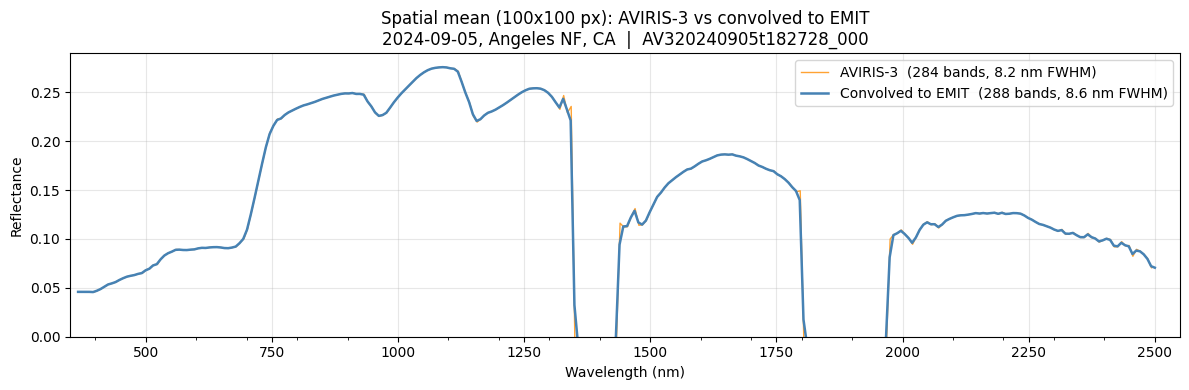

Saved: data/spectrum_comparison.png


In [14]:
# 100x100 px mean near scene center
r0, c0 = av3_data.shape[0] // 2 - 50, av3_data.shape[1] // 2 - 50
mean_av3  = np.nanmean(av3_data[r0:r0+100, c0:c0+100, :],    axis=(0, 1))
mean_emit = np.nanmean(av3_as_emit[r0:r0+100, c0:c0+100, :], axis=(0, 1))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(av3.wavelengths,  mean_av3,  lw=1,   color="darkorange", alpha=0.8,
        label=f"AVIRIS-3  ({len(av3.wavelengths)} bands, {av3.fwhm.mean():.1f} nm FWHM)")
ax.plot(emit.wavelengths, mean_emit, lw=1.8, color="steelblue",
        label=f"Convolved to EMIT  ({len(emit.wavelengths)} bands, {emit.fwhm.mean():.1f} nm FWHM)")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.set_title(
    "Spatial mean (100x100 px): AVIRIS-3 vs convolved to EMIT\n"
    "2024-09-05, Angeles NF, CA  |  AV320240905t182728_000"
)
ax.legend()
ax.set_xlim(350, 2550)
ax.set_ylim(0, None)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(data_dir / "spectrum_comparison.png", dpi=150)
plt.show()
print(f"Saved: {data_dir / 'spectrum_comparison.png'}")

### 8b. RGB quicklooks


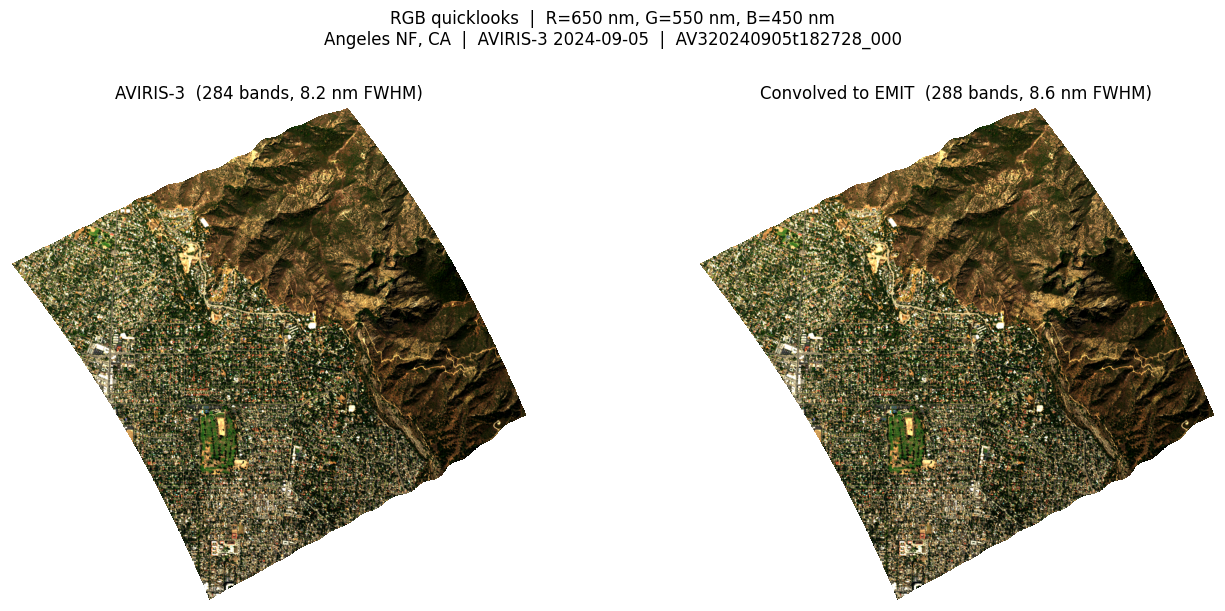

Saved: data/rgb_quicklooks.png


In [15]:
def make_rgb(d, wl, r_nm=650, g_nm=550, b_nm=450):
    def nearest(w): return int(np.argmin(np.abs(wl - w)))
    rgb = np.stack([d[:, :, nearest(r_nm)],
                    d[:, :, nearest(g_nm)],
                    d[:, :, nearest(b_nm)]], axis=-1)
    p2, p98 = np.nanpercentile(rgb, 2), np.nanpercentile(rgb, 98)
    return np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(make_rgb(av3_data, av3.wavelengths))
axes[0].set_title(f"AVIRIS-3  ({av3_data.shape[2]} bands, {av3.fwhm.mean():.1f} nm FWHM)")
axes[0].axis("off")
axes[1].imshow(make_rgb(av3_as_emit, emit.wavelengths))
axes[1].set_title(f"Convolved to EMIT  ({av3_as_emit.shape[2]} bands, {emit.fwhm.mean():.1f} nm FWHM)")
axes[1].axis("off")
plt.suptitle(
    "RGB quicklooks  |  R=650 nm, G=550 nm, B=450 nm\n"
    "Angeles NF, CA  |  AVIRIS-3 2024-09-05  |  AV320240905t182728_000",
    y=1.01,
)
plt.tight_layout()
plt.savefig(data_dir / "rgb_quicklooks.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {data_dir / 'rgb_quicklooks.png'}")

### 8c. SRF convolution vs naive linear interpolation

The two methods look similar on a smooth spectrum because AVIRIS-3 and EMIT have
similar spectral resolution (~7-9 nm FWHM). The differences are real but small
(max ~1.3% reflectance units) and concentrate at the **edges** of water vapour
absorption features (~1340 nm and ~1800 nm) where the spectrum changes steeply.
This is exactly where proper SRF convolution matters: steep gradients are weighted
differently by a Gaussian than by linear interpolation.


/var/folders/4y/vdf6lk8d18qf_nvdqb40_nfw0000gn/T/ipykernel_13559/395567831.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


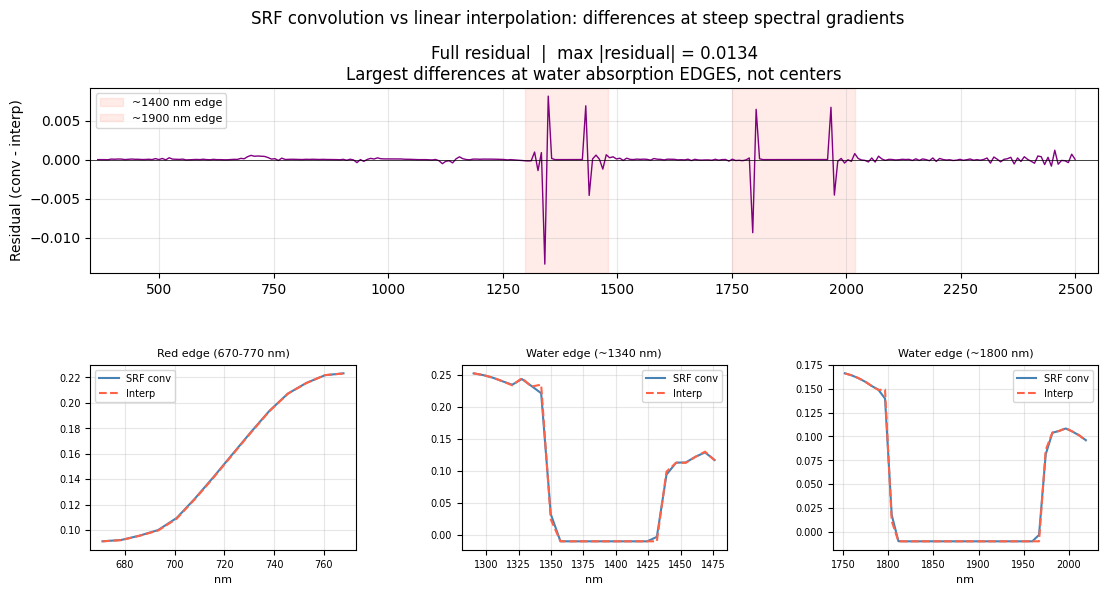

Saved: data/residual_comparison.png


In [16]:
mean_interp = np.interp(emit.wavelengths, av3.wavelengths, mean_av3)
residual    = mean_emit - mean_interp

fig = plt.figure(figsize=(13, 6))
gs  = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.4)
ax_main = fig.add_subplot(gs[0, :])
ax_re   = fig.add_subplot(gs[1, 0])
ax_w1   = fig.add_subplot(gs[1, 1])
ax_w2   = fig.add_subplot(gs[1, 2])

ax_main.plot(emit.wavelengths, residual, color="purple", lw=1)
ax_main.axhline(0, color="k", lw=0.5)
for wl_range, label in [((1300, 1480), "~1400 nm edge"), ((1750, 2020), "~1900 nm edge")]:
    ax_main.axvspan(wl_range[0], wl_range[1], alpha=0.12, color="tomato", label=label)
ax_main.legend(fontsize=8, loc="upper left")
ax_main.set_ylabel("Residual (conv - interp)")
ax_main.set_title(
    f"Full residual  |  max |residual| = {np.nanmax(np.abs(residual)):.4f}\n"
    "Largest differences at water absorption EDGES, not centers"
)
ax_main.set_xlim(350, 2550)
ax_main.grid(True, alpha=0.3)

for ax, wl_range, title in [
    (ax_re, (670, 770),   "Red edge (670-770 nm)"),
    (ax_w1, (1290, 1480), "Water edge (~1340 nm)"),
    (ax_w2, (1750, 2020), "Water edge (~1800 nm)"),
]:
    mask = (emit.wavelengths >= wl_range[0]) & (emit.wavelengths <= wl_range[1])
    ax.plot(emit.wavelengths[mask], mean_emit[mask],   color="steelblue", lw=1.5, label="SRF conv")
    ax.plot(emit.wavelengths[mask], mean_interp[mask], color="tomato",    lw=1.5, ls="--", label="Interp")
    ax.set_title(title, fontsize=8)
    ax.set_xlabel("nm", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

plt.suptitle(
    "SRF convolution vs linear interpolation: differences at steep spectral gradients",
    y=1.01,
)
plt.tight_layout()
plt.savefig(data_dir / "residual_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {data_dir / 'residual_comparison.png'}")

---
## 9. Save convolved data

The three figures above were saved alongside each plot.
Here we write the convolved reflectance array to `data/` in two formats:

- **NetCDF4** (`.nc`) — spatially referenced with EMIT wavelengths, FWHM,
  and the easting/northing grids from the original AVIRIS-3 file.
- **NumPy** (`.npy`) — flat array, loads instantly with `np.load()`.


In [17]:
import h5py

# ── NetCDF4 (HDF5-backed, gzip compressed) ───────────────────────────────
nc_out = data_dir / "AV320240905t182728_000_convolved_to_EMIT.nc"

with h5py.File(nc_out, "w") as f:
    f.attrs["source_granule"]    = "AV320240905t182728_000_L2A_RFL_1"
    f.attrs["source_date"]       = "2024-09-05"
    f.attrs["target_instrument"] = "EMIT"
    f.attrs["convolution"]       = "Gaussian SRF (srfforge BandConvolver)"

    grp = f.create_group("reflectance")

    ds = grp.create_dataset(
        "reflectance",
        data=av3_as_emit.astype(np.float32),
        compression="gzip", compression_opts=4,
    )
    ds.attrs["_FillValue"] = np.float32(-9999.0)
    ds.attrs["long_name"]  = "Surface reflectance convolved to EMIT spectral sampling"
    ds.attrs["units"]      = "unitless"

    wl_ds = grp.create_dataset("wavelengths", data=emit.wavelengths.astype(np.float32))
    wl_ds.attrs["units"]     = "nm"
    wl_ds.attrs["long_name"] = "EMIT band centre wavelengths (nominal)"

    fw_ds = grp.create_dataset("fwhm", data=emit.fwhm.astype(np.float32))
    fw_ds.attrs["units"]     = "nm"
    fw_ds.attrs["long_name"] = "EMIT FWHM per band (nominal)"

    # Copy spatial coordinates from the original AVIRIS-3 file
    with h5py.File(av3_nc, "r") as src:
        f.create_dataset("easting",  data=src["easting"][:])
        f.create_dataset("northing", data=src["northing"][:])
        if "transverse_mercator" in src:
            f.create_dataset("transverse_mercator", data=src["transverse_mercator"][()])

print(f"Saved NetCDF4 : {nc_out.name}  ({nc_out.stat().st_size / 1e6:.0f} MB)")

# ── NumPy (uncompressed, fast to reload) ──────────────────────────────────
npy_out = data_dir / "AV320240905t182728_000_convolved_to_EMIT.npy"
np.save(npy_out, av3_as_emit.astype(np.float32))
print(f"Saved NumPy   : {npy_out.name}  ({npy_out.stat().st_size / 1e6:.0f} MB)")

print()
print("All outputs in:", data_dir.resolve())


Saved NetCDF4 : AV320240905t182728_000_convolved_to_EMIT.nc  (1196 MB)


OSError: 708151680 requested and 536870912 written